# Pure/Mixed State Preparation
How do we prepare an arbitrary $n$-qubit state starting from $n$ clean qubits? This is obviously an important question, so it barely deserves motivation. What if the state is not pure, but mixed? How do we encode a density matrix? We suppose that the pure state $\psi$ and the mixed state $\rho$ are known--the problem is to evolve these starting from a clean register using known gates.

We can break the pure state procedure into two steps. Let us write our pure state as
$$
|\psi\rangle = \sum_x \psi_x |x\rangle = \sum_x |\psi_x| e^{i2\pi\theta(x)} |x\rangle 
$$
where $x \in \mathbb{F}_2^n$. We will use multiplexed rotations to prepare the state $|\psi'\rangle = \sum_x |\psi_x| |x\rangle$. Then will use a diagonal unitary to append this state with the phases $\mathcal{D}_\theta |x\rangle = e^{i2\pi\theta(x)} |x\rangle$.

Preparing the mixed state requires some extra steps. We start with the density operator
$$
\rho = \sum_{i=0}^{M-1} p_i | \psi_i \rangle \langle \psi_i |
$$
where $\sum_{i} p_i = 1$ or equivalently $\text{Tr}(\rho)=1$ and $M \neq 2^n$ in general. The $| \psi_i \rangle$ are a collection of not necessarily orthogonal states. The first thing to do, which is a classical preprocessing step, is to diagonalize $\rho$:
\begin{equation}
\rho = \sum_{i=0}^{2^n-1} \lambda_i | e_i \rangle \langle e_i |
\end{equation}
Then we wish to prepare the following state; this step is called purification
$$
|\Psi\rangle = \sum_{i=0}^{2^n-1} \sqrt{\lambda_i} | e_i \rangle |i\rangle
$$
Why this state? Because this state has the same statistics as the density matrix in the sense that if we measure the ancilla qubits and we obtain $j$ with probability $\lambda_j$, then the remaining qubits are in the state $ | e_j \rangle$. In addition, if we measure an observable $\mathcal{O}$ on the first set of qubits after this, we will obtain, on average
\begin{equation}
\sum_{i=0}^{2^n-1} \lambda_i \langle e_i | \mathcal{O} | e_i \rangle = \text{Tr}(\mathcal{O} \rho)
\end{equation}
which is exactly what we need.

## Imports
We use Qiskit for circuit construction and statevector verification, and NumPy for the classical preprocessing steps.

In [25]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.transpiler.passes import RemoveBarriers
from qiskit.transpiler import PassManager

import numpy as np

## QROM and Diagonal Phases
The QROM loads a classical table of phase bits into an ancilla register. The diagonal unitary then applies a $P(1)$ gate and uncomputes the QROM. The `mcx` calls are Qiskit conveniences for selecting a bit string; they can be decomposed into one-qubit gates and multi-controlled phase/Z-type operations by conjugating the target with Hadamards.

In [ ]:
def qrom_loader(quantum_keys, quantum_values, theta_d):
    n = len(quantum_keys)
    d = len(quantum_values)
    circuit = QuantumCircuit(quantum_keys, quantum_values, name=r"$U_\theta$")
    for x in range(2**n):
        x_bits = (x >> np.arange(n)) % 2
        flip = [quantum_keys[i] for i in range(n) if x_bits[i] == 0]
        for q in flip:
            circuit.x(q)
        for y in range(d):
            if theta_d[x][y] == 1:
                circuit.mcx(quantum_keys, quantum_values[y])
        for q in flip:
            circuit.x(q)
        circuit.barrier()
    return circuit


def diagonal_unitary_circ(phases, d, loader=None):
    # phases: list/array of length 2**n, theta(x) in [0, 1)
    # builds |x> -> exp(i*2*pi*theta(x)) |x>, truncated to d bits
    phases = np.asarray(phases)
    n = int(np.log2(len(phases)))
    assert 2**n == len(phases), "len(phases) must be a power of 2"

    # Digitize theta
    theta_d = (np.floor(phases * (2**d)).astype(int).reshape(-1, 1) >> np.arange(d)) % 2

    quantum_keys = QuantumRegister(size=n, name="x")
    quantum_values = AncillaRegister(size=d, name="y")

    if loader is None:
        loader = qrom_loader
    select_qrom = loader(quantum_keys, quantum_values, theta_d)

    pm = PassManager(RemoveBarriers())
    qrom_gate = pm.run(select_qrom).to_gate(label="QROM")
    qrom_gate_inverse = qrom_gate.inverse()

    main_register = QuantumRegister(size=n, name="x")
    ancillas = AncillaRegister(size=d, name="memory")
    diagonal_unitary = QuantumCircuit(main_register, ancillas, name="D_theta")

    diagonal_unitary.compose(qrom_gate, inplace=True)

    # P(1)
    diagonal_unitary.barrier(ancillas[:d])
    for idx, q in enumerate(reversed(ancillas[:d])):
        diagonal_unitary.p(np.pi / (1 << idx), q)
    diagonal_unitary.barrier(ancillas[:d])

    diagonal_unitary.compose(qrom_gate_inverse, inplace=True)

    return diagonal_unitary

## Non-Negative Amplitude Preparation
These functions prepare the real non-negative state $\sum_x |\psi_x||x\rangle$. The angles are computed from probability mass splits in the amplitude tree. The `mcry` calls are Qiskit shorthand for multiplexed $R_y$ rotations; again, multiplexed $R_y$ rotations can be implemented from multiplexed $R_z$ rotations using one-qubit basis changes.

In [6]:
def recursive_ry_angles(moduli):
    # moduli: array of length 2**n, the non-negative |psi_x|
    # returns: list of n arrays; angles[l] has length 2**l, giving the
    # multiplexed R_Y angle theta(c) at recursion level l (l controls)
    moduli = np.asarray(moduli, dtype=float)
    n = int(np.log2(len(moduli)))
    assert 2**n == len(moduli), "len(moduli) must be a power of 2"

    probs = moduli**2
    angles = []
    for l in range(n):
        # split probs into (undecided-upper-bits, this-bit, already-decided c)
        upper = 2**(n - l - 1)
        marg = probs.reshape(upper, 2, 2**l).sum(axis=0)  # shape (2, 2**l)
        p0, p1 = marg[0], marg[1]
        total = p0 + p1
        with np.errstate(invalid="ignore", divide="ignore"):
            theta = 2 * np.arccos(np.sqrt(np.where(total > 0, p0 / total, 1.0)))
        angles.append(theta)
    return angles


def state_prep_circuit(moduli):
    # builds |0...0> -> sum_x moduli[x] |x>  (moduli normalized internally)
    moduli = np.asarray(moduli, dtype=float)
    moduli = moduli / np.linalg.norm(moduli)
    n = int(np.log2(len(moduli)))
    angles = recursive_ry_angles(moduli)

    q = QuantumRegister(size=n, name="x")
    circuit = QuantumCircuit(q, name=r"$U_{|\psi'\rangle}$")

    for l in range(n):
        # qubit q[l] is decided at level l, controlled by q[0..l-1]
        target = q[l]
        controls = [q[i] for i in range(l)]
        theta = angles[l]

        if l == 0:
            circuit.ry(theta[0], target)
        else:
            for c in range(2**l):
                c_bits = (c >> np.arange(l)) % 2
                flip = [controls[i] for i in range(l) if c_bits[i] == 0]
                for qq in flip:
                    circuit.x(qq)
                circuit.mcry(theta[c], controls, target)
                for qq in flip:
                    circuit.x(qq)
                circuit.barrier()
        circuit.barrier()

    return circuit

## Pure-State Circuit Assembly
This example combines the non-negative amplitude preparation with the diagonal phase unitary to build a circuit for a random complex pure state.

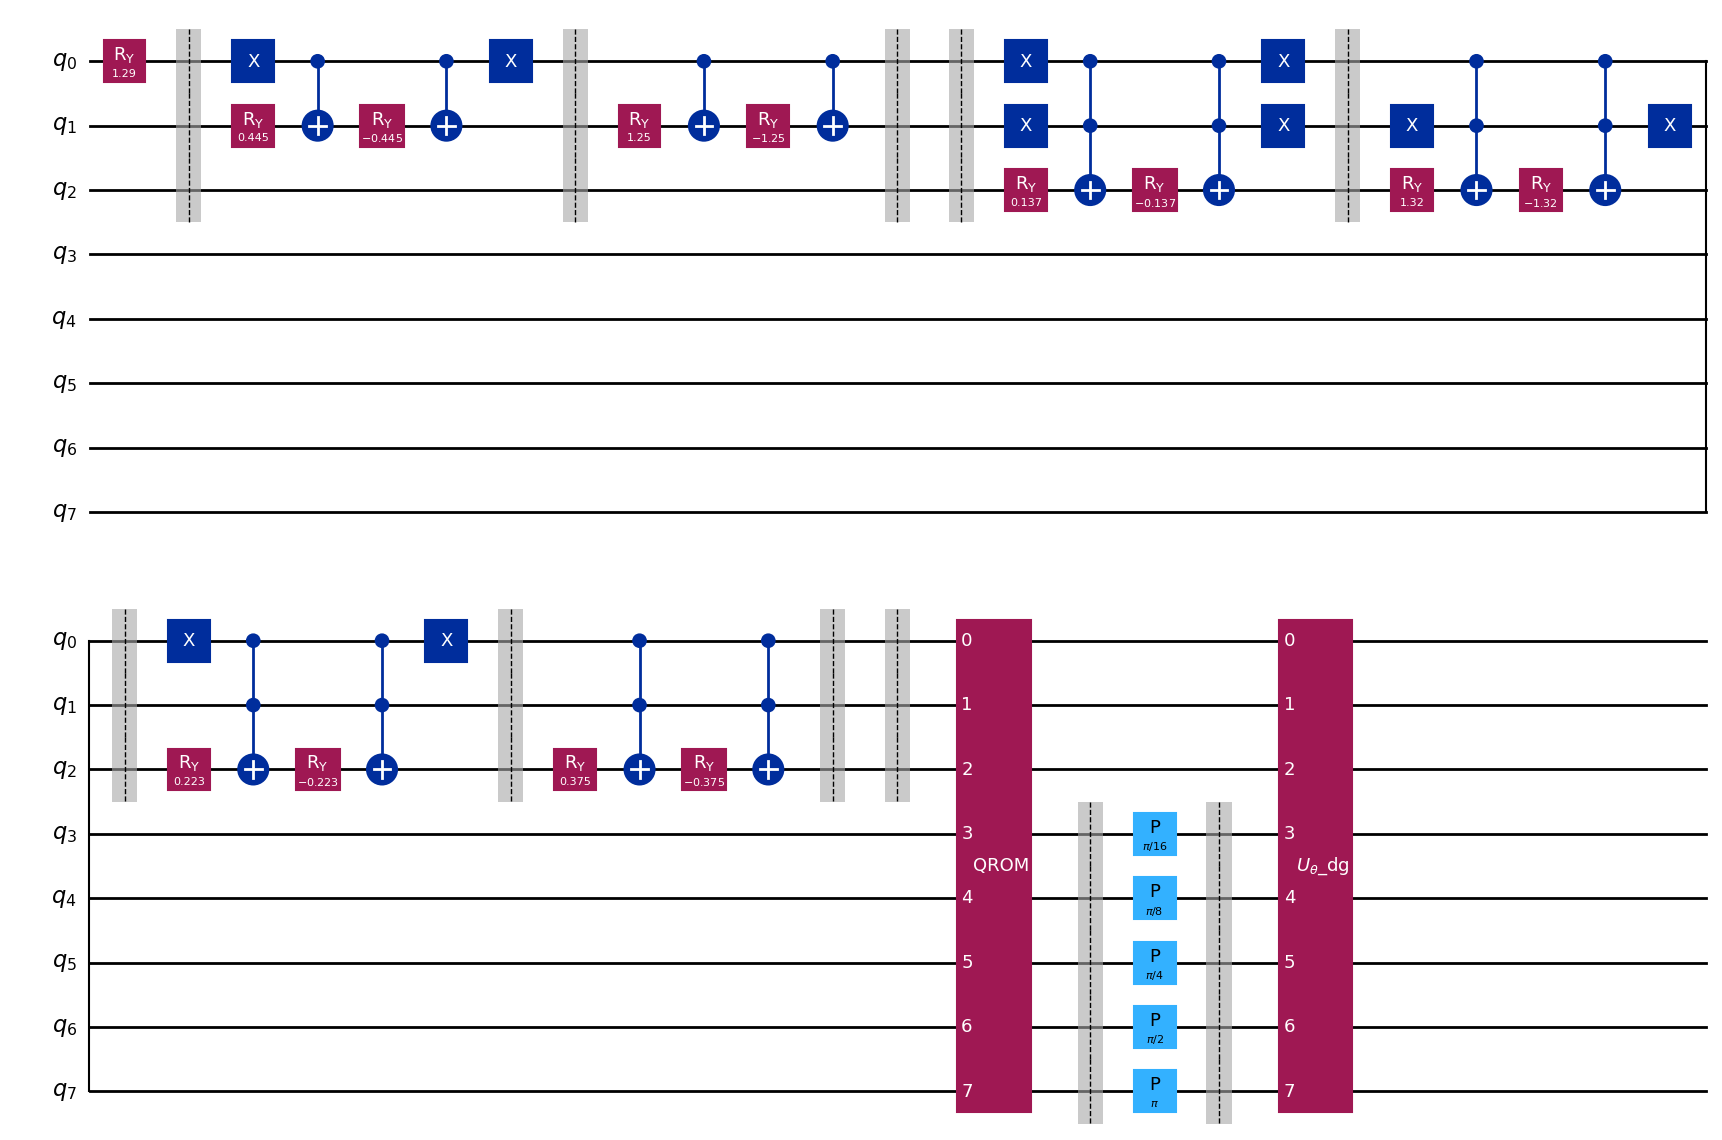

In [7]:
n = 3
psi = np.random.randn(2**n) + 1j*np.random.randn(2**n)
psi = psi / np.linalg.norm(psi)

moduli = np.abs(psi)
thetas = (np.angle(psi) % (2*np.pi)) / (2*np.pi)   # fraction of a turn, in [0,1)

state_prep = state_prep_circuit(moduli)
diagonal_unitary = diagonal_unitary_circ(thetas, d=5)   # from earlier

full = QuantumCircuit(n + diagonal_unitary.num_qubits - n)
full.compose(state_prep, qubits=range(n), inplace=True)
full.compose(diagonal_unitary, qubits=range(full.num_qubits), inplace=True)
full.draw(output="mpl")

## Check the Real-Amplitude Subroutine
This verifies that the $R_y$ multiplex step prepares the desired non-negative amplitudes before phases are added.

In [12]:
from qiskit.quantum_info import Statevector

moduli = np.random.rand(2**n)
moduli = moduli / np.linalg.norm(moduli)

sv = Statevector(state_prep_circuit(moduli)).data

print(np.allclose(np.abs(sv), moduli))   # magnitudes match
print(np.allclose(np.imag(sv), 0))       # purely real

True
True


## Check Full Pure-State Preparation
Here the diagonal unitary adds the complex phases. The comparison allows error on the order of the phase truncation precision.

In [ ]:
d = 10
psi = np.random.randn(2**n) + 1j*np.random.randn(2**n)
psi = psi / np.linalg.norm(psi)

moduli = np.abs(psi)
thetas = (np.angle(psi) % (2*np.pi)) / (2*np.pi)

state_prep = state_prep_circuit(moduli)
diagonal_unitary = diagonal_unitary_circ(thetas, d=d)

n_total = diagonal_unitary.num_qubits
full = QuantumCircuit(n_total)
full.compose(state_prep, qubits=range(n), inplace=True)
full.compose(diagonal_unitary, qubits=range(n_total), inplace=True)

sv = Statevector(full).data
amp = sv[:2**n]            # ancillas should have returned to |0>

print(np.allclose(amp, psi, atol=2**(-d) * 5))  # matches target to d-bit precision

True


## Mixed-State Preparation Function
The function diagonalizes $\rho$, builds a purification $\sum_i \sqrt{\lambda_i}|e_i\rangle|i\rangle$, prepares that pure state, and measures the index register.

In [ ]:
def mixed_state_prep(rho, d=10):
    rho = np.asarray(rho, dtype=complex)
    N = rho.shape[0]
    n = int(np.log2(N))

    # Perform basic checks
    assert rho.shape == (N, N),                              "rho must be square"
    assert 2**n == N,                                        "dimension must be a power of 2"
    assert np.allclose(rho, rho.conj().T, atol=1e-10),      "rho must be Hermitian"
    assert np.isclose(np.trace(rho).real, 1.0, atol=1e-10), "trace(rho) must be 1"

    # Diagonalize: rho = sum_i lambda_i |e_i><e_i|
    lambdas, evecs = np.linalg.eigh(rho)     # evecs[:, i] = |e_i>, ascending order
    assert np.all(lambdas >= -1e-10),         "rho must be positive semidefinite"
    lambdas = np.clip(lambdas, 0, None)

    # Build purification vector: |Psi> = sum_i sqrt(lambda_i) |e_i>|i>
    # Qiskit ordering: psi[j + i*N] = sqrt(lambda_i) * evecs[j, i]
    psi = np.zeros(N * N, dtype=complex)
    for i in range(N):
        psi[np.arange(N) + i * N] = np.sqrt(lambdas[i]) * evecs[:, i]

    # Prepare |Psi> on 2n qubits
    moduli = np.abs(psi)
    thetas = (np.angle(psi) % (2*np.pi)) / (2*np.pi)

    sp = state_prep_circuit(moduli)          # 2n-qubit circuit
    du = diagonal_unitary_circ(thetas, d=d)  # (2n + d)-qubit circuit

    n2      = 2 * n
    n_total = du.num_qubits

    system_reg = QuantumRegister(size=n,            name="system")
    index_reg  = QuantumRegister(size=n,            name="index")
    memory_reg = AncillaRegister(size=n_total - n2, name="memory")
    c_index    = ClassicalRegister(size=n,          name="c_index")

    circuit = QuantumCircuit(system_reg, index_reg, memory_reg, c_index)
    circuit.compose(sp, qubits=range(n2),      inplace=True)
    circuit.compose(du, qubits=range(n_total), inplace=True)
    circuit.measure(index_reg, c_index)

    return circuit

## Verify the Reduced State
This verification reconstructs the statevector before measurement and traces out the index register by summing over the purification label.

In [22]:
def verify_mixed_state_prep(rho, d=10):
    rho = np.asarray(rho, dtype=complex)
    N = rho.shape[0]; n = int(np.log2(N))
    lambdas, evecs = np.linalg.eigh(rho)
    lambdas = np.clip(lambdas, 0, None)
    psi = np.zeros(N*N, dtype=complex)
    for i in range(N):
        psi[np.arange(N) + i*N] = np.sqrt(lambdas[i]) * evecs[:, i]
    moduli = np.abs(psi); thetas = (np.angle(psi) % (2*np.pi)) / (2*np.pi)
    sp = state_prep_circuit(moduli); du = diagonal_unitary_circ(thetas, d=d)
    n2 = 2*n; n_total = du.num_qubits
    full = QuantumCircuit(n_total)
    full.compose(sp, qubits=range(n2), inplace=True)
    full.compose(du, qubits=range(n_total), inplace=True)
    sv = Statevector(full).data
    # memory ancillas back to |0>: first N*N entries have memory=0
    amp = sv[:N*N].reshape(N, N)     # amp[i, j] = amplitude of |system=j, index=i>
    rho_out = amp.T @ amp.conj()     # rho_out[j,j'] = sum_i amp[i,j] * conj(amp[i,j'])
    tol = 5 * 2**(-d)
    print("rho recovered:       ", np.allclose(rho_out, rho, atol=tol))
    print("max error:           ", np.max(np.abs(rho_out - rho)))
    return rho_out

## Demo for n = 2
This creates a random valid density matrix on two qubits and checks that the preparation routine recovers it after tracing out the index register.

In [24]:
n = 2  # vary this

N = 2**n
A = np.random.randn(N, N) + 1j * np.random.randn(N, N)
rho = A @ A.conj().T
rho = rho / np.trace(rho)

verify_mixed_state_prep(rho, d=10)

rho recovered:        True
max error:            0.0009109611319947989


array([[ 0.28389079+1.36734678e-33j,  0.02042924+7.32901192e-02j,
         0.03049241+1.29466928e-01j, -0.04827833+1.58619983e-01j],
       [ 0.02042924-7.32901192e-02j,  0.19596765+3.37567007e-18j,
        -0.0308895 -1.83133256e-02j,  0.07745005+3.52097100e-02j],
       [ 0.03049241-1.29466928e-01j, -0.0308895 +1.83133256e-02j,
         0.30487122-5.87195535e-19j,  0.0049232 +1.70206613e-01j],
       [-0.04827833-1.58619983e-01j,  0.07745005-3.52097100e-02j,
         0.0049232 -1.70206613e-01j,  0.21527034-4.21894506e-18j]])